# Challenge EEIA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn")

/tmp/ipykernel_4343/4109155056.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


# Load data

Here we define the directory path where the data is stored and will be stored. The files train.csv and test.csv should be in that directory.

In [2]:
data_path = ''

In [3]:
data = pd.read_csv(f'{data_path}train.csv',delimiter=';',decimal=',',na_values=["#VALEUR!"],index_col="time")
data.index = pd.to_datetime(data.index, format='%d/%m/%Y %H:%M')

test = pd.read_csv(f'{data_path}test.csv',delimiter=';',decimal=',',na_values=["#VALEUR!"],index_col="time")
test.index = pd.to_datetime(test.index, format='%d/%m/%Y %H:%M')

The following cell displays the first rows of the dataframe.

In [4]:
data.head()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
time,,,,,,,,,,,,
2022-01-01 00:00:00,2.415345,13.756624,1009.650948,77.891805,NaN,44.799709,NaN,25523.87408,1.566854,-1.289541,-1.575997,8.292017
2022-01-01 00:01:00,2.410162,13.754808,1009.653573,78.010106,NaN,44.799660,NaN,25523.87408,1.566860,-1.284832,-1.575923,8.300175
2022-01-01 00:02:00,2.404979,13.752992,1009.656258,78.128415,NaN,44.799614,NaN,25523.87408,1.566866,-1.280124,-1.575849,8.308332
2022-01-01 00:03:00,2.399796,13.751176,1009.658883,78.246716,NaN,44.799565,NaN,25523.87408,1.566872,-1.275416,-1.575776,8.316489
2022-01-01 00:04:00,2.394613,13.749360,1009.658883,78.365018,NaN,44.799519,NaN,25523.87408,1.566878,-1.270708,-1.575702,8.324646


In [5]:
test.head()

test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 156960 entries, 2022-04-01 00:00:00 to 2022-12-31 23:59:00
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Amb temp °C                   156960 non-null  float64
 1   Comp inlet temp °C            156960 non-null  float64
 2   amb pressure                  156960 non-null  float64
 3   HR %                          156960 non-null  float64
 4   C/H                           156960 non-null  float64
 5   Network Frequency (Hz)        156960 non-null  float64
 6   Lower Heating Value (Wh/Nm3)  156960 non-null  float64
 7   EOH (h)                       156960 non-null  float64
 8   DP filtre                     156960 non-null  float64
 9   CTRL anti givrage             156960 non-null  float64
 10  IGV %                         156960 non-null  float64
 11  Net Power (MW)                0 non-null       float64
dtypes: float64

Getting the shape of the dataframe

In [6]:
data.shape, test.shape

((297316, 12), (156960, 12))

The training set contains 368591 rows andd 12 columns and the test set contains 156960 rows and 12 columns. The test set contains almost half less data than the training set. All the values in the column Net Power (MW) are NaN and should be filled with our model's predictions.

Here are the list of the columns of both dataset : 

<table border="0" padding="0" margin="0">
<tbody>
<tr><td>Amb temp (°C)</td><td>Température ambiante</td></tr>
<tr><td>Comp inlet temp (°C)</td><td>Température entrée compresseur</td></tr>
<tr><td>amb pressure</td><td>Pression ambiante</td></tr>
<tr><td>HR %</td><td>%Humidité relative ambiante</td></tr>
<tr><td>C/H</td><td>Rapport Carbonne/hydrogène du Gaz Nat</td></tr>
<tr><td>Network Frequency (Hz)</td><td>Fréquence du réseau électrique en Hz</td></tr>
<tr><td>Lower Heating Value (Wh/Nm3) &nbsp;</td><td>le pouvoir calorifique inférieur du Gaz Nat</td></tr>
<tr><td>EOH (h)</td><td>Heures d'Opérations Equivalentes </td></tr>
<tr><td>DP filtre</td><td>Perte de charge au niveau des filtres d'air entrée turbine à gaz</td></tr>
<tr><td>CTRL anti givrage</td><td>Control de la vanne d'ouverture de l'anti-givre entrée turbine gaz</td></tr>
<tr><td>IGV %</td><td>% d'ouverture de la valve IGV (Inlet Guide Vanes) afin de controller la charge de la CCGT</td></tr>
<tr><td>Net Power (MW)</td><td>Production d'électricité NETTE générée par la CCGT</td></tr>
</tbody>
</table>

# Checks

We check that this data has the exact types we are waiting for.

In [7]:
assert data.dtypes.equals(pd.Series(dict(zip(data.columns,["float64"]*len(data.columns)))))

assert test.dtypes.equals(pd.Series(dict(zip(test.columns,["float64"]*len(test.columns)))))

Statistical metrics of the training set such as the minimum, average, standard deviation, maximum, and quantiles are computed below.

In [8]:
data.head()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
time,,,,,,,,,,,,
2022-01-01 00:00:00,2.415345,13.756624,1009.650948,77.891805,NaN,44.799709,NaN,25523.87408,1.566854,-1.289541,-1.575997,8.292017
2022-01-01 00:01:00,2.410162,13.754808,1009.653573,78.010106,NaN,44.799660,NaN,25523.87408,1.566860,-1.284832,-1.575923,8.300175
2022-01-01 00:02:00,2.404979,13.752992,1009.656258,78.128415,NaN,44.799614,NaN,25523.87408,1.566866,-1.280124,-1.575849,8.308332
2022-01-01 00:03:00,2.399796,13.751176,1009.658883,78.246716,NaN,44.799565,NaN,25523.87408,1.566872,-1.275416,-1.575776,8.316489
2022-01-01 00:04:00,2.394613,13.749360,1009.658883,78.365018,NaN,44.799519,NaN,25523.87408,1.566878,-1.270708,-1.575702,8.324646


In [9]:
data.describe()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
count,297237.000000,297252.000000,297307.000000,297288.000000,297271.000000,296954.000000,296798.000000,295737.000000,297288.000000,297254.000000,297075.000000,296941.000000
mean,15.008851,20.529445,991.409109,59.440738,3.290688,44.663514,10778.503672,26740.483788,2.393102,-11.449428,15.949354,90.052975
std,8.028309,7.368423,8.592779,17.841287,0.015477,1.278126,116.305145,581.332603,1.570001,7.450464,36.279566,155.028722
min,-1.092109,1.520982,948.226082,5.427441,3.208825,41.268475,518.654730,25523.874080,1.227618,-38.742719,-3.580509,1.259763
25%,7.802657,15.847379,986.729287,46.216865,3.278702,44.772968,10741.462655,26342.059630,1.564353,-16.415948,-2.733973,8.804905
50%,15.089391,21.816917,992.181588,63.009892,3.291795,44.785591,10769.057385,27019.401420,1.575010,-11.204905,-2.544281,9.588691
75%,20.482010,25.728443,996.617654,74.505578,3.302844,44.798996,10816.214055,27314.919000,1.624453,-4.576472,3.741719,10.540897
max,42.857579,41.147633,1012.865487,91.678914,3.378507,46.347027,10989.565000,27530.360410,6.598876,0.997576,103.868595,434.143647


# EDA and first models

In [10]:
data.isna().sum()

test.isna().sum()

Amb temp °C                          0
Comp inlet temp °C                   0
amb pressure                         0
HR %                                 0
C/H                                  0
Network Frequency (Hz)               0
Lower Heating Value (Wh/Nm3)         0
EOH (h)                              0
DP filtre                            0
CTRL anti givrage                    0
IGV %                                0
Net Power (MW)                  156960
dtype: int64

There are 3388 NaN values in the dataframe.

### Imputing strategy

In [11]:
from sklearn.impute import SimpleImputer

In [12]:
# Dropping all the NaN values
# data.dropna(inplace=True)

# Replace the Nans using a given strategy

chosen_strategy = 'median' # "mean" / "constant" / "most_frequent"
for col in data.columns:
    imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
    data[col] = imp_mean.fit_transform(data[[col]]).squeeze()

In [13]:
assert (data.isna().sum(axis=0).sum() == 0)

Let's start by checking all the variables

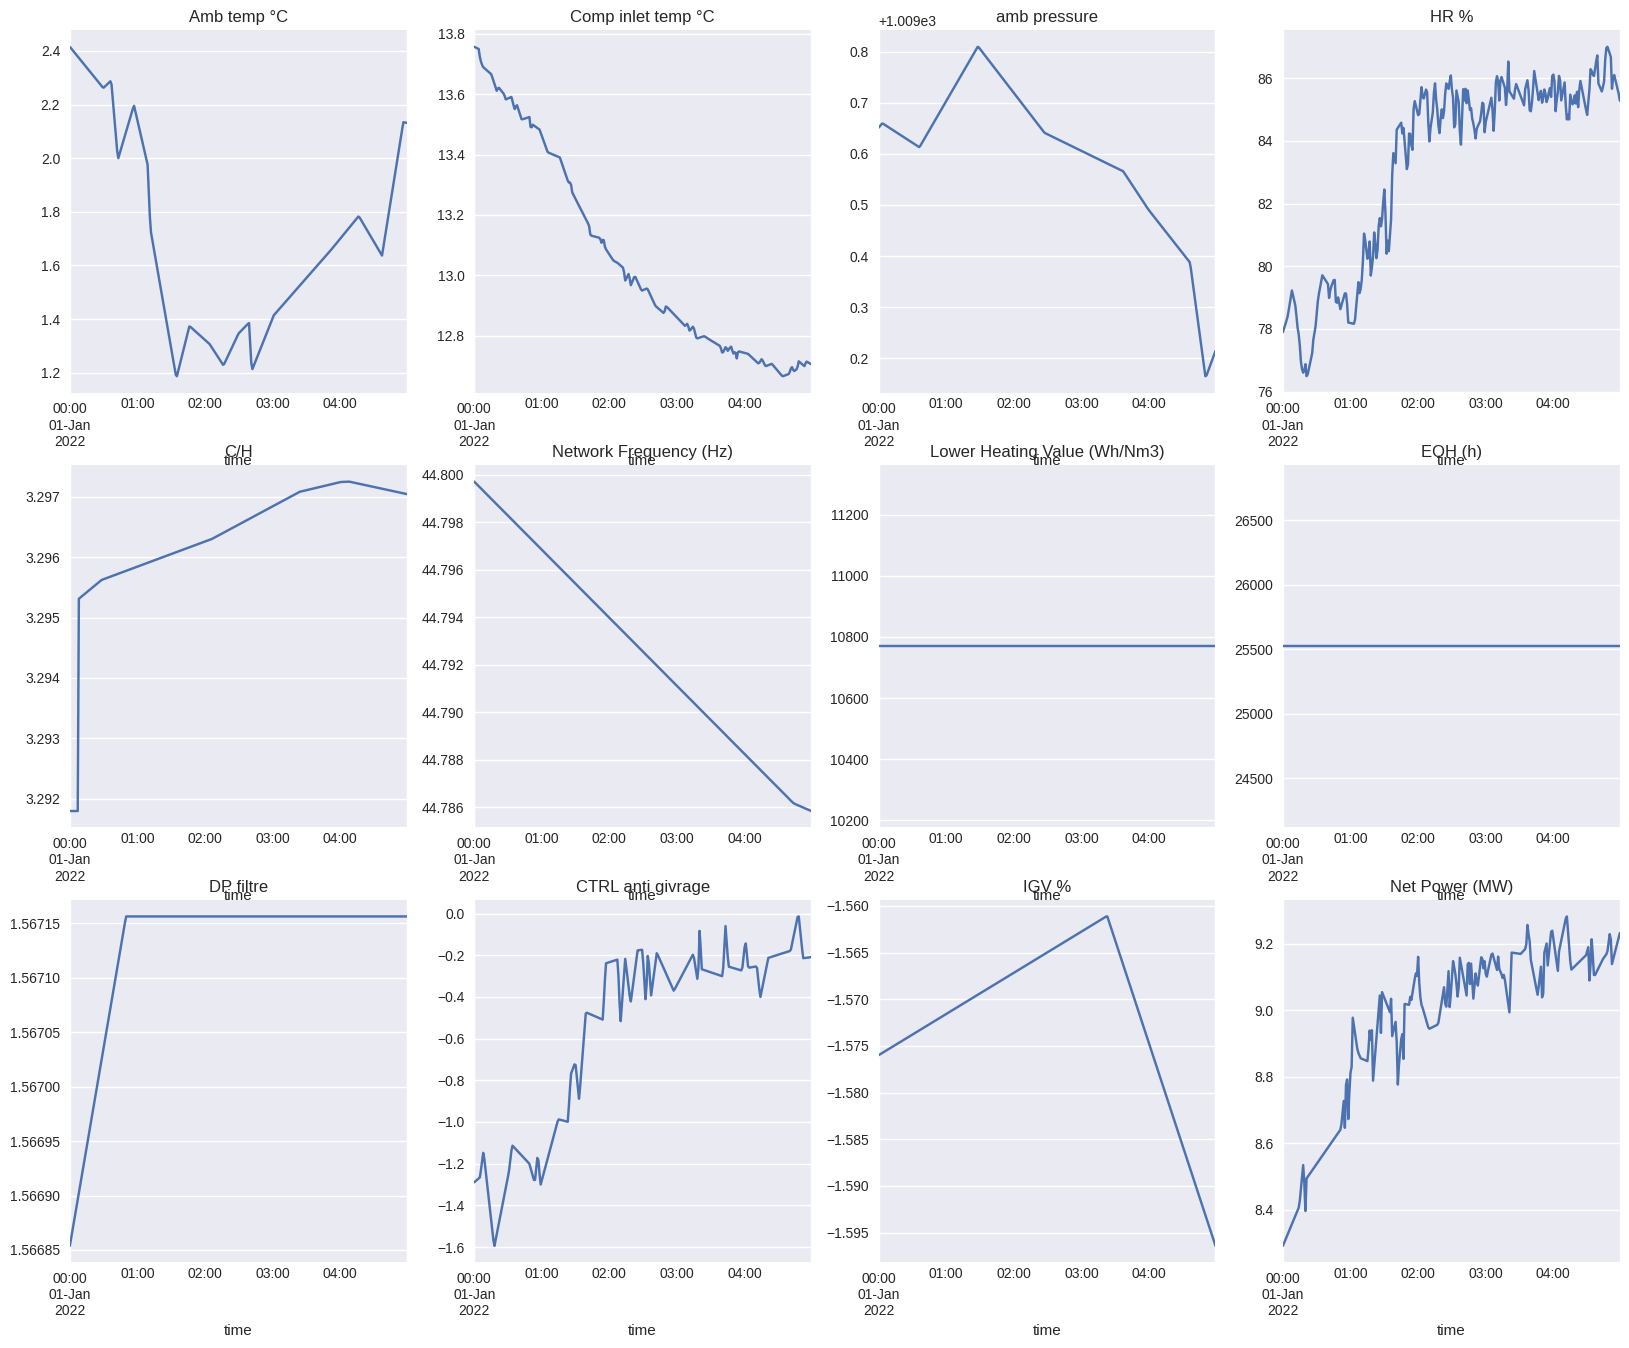

In [14]:
fig, ax = plt.subplots(figsize=(20,16),nrows=3, ncols=4)

for i,col in enumerate(data.columns):
    data.head(300)[col].plot(ax=ax[i//4,i%4],title=col)

array([[<Axes: title={'center': 'Amb temp °C'}>,
        <Axes: title={'center': 'Comp inlet temp °C'}>,
        <Axes: title={'center': 'amb pressure'}>],
       [<Axes: title={'center': 'HR %'}>,
        <Axes: title={'center': 'C/H'}>,
        <Axes: title={'center': 'Network Frequency (Hz)'}>],
       [<Axes: title={'center': 'Lower Heating Value (Wh/Nm3)'}>,
        <Axes: title={'center': 'EOH (h)'}>,
        <Axes: title={'center': 'DP filtre'}>],
       [<Axes: title={'center': 'CTRL anti givrage'}>,
        <Axes: title={'center': 'IGV %'}>,
        <Axes: title={'center': 'Net Power (MW)'}>]], dtype=object)

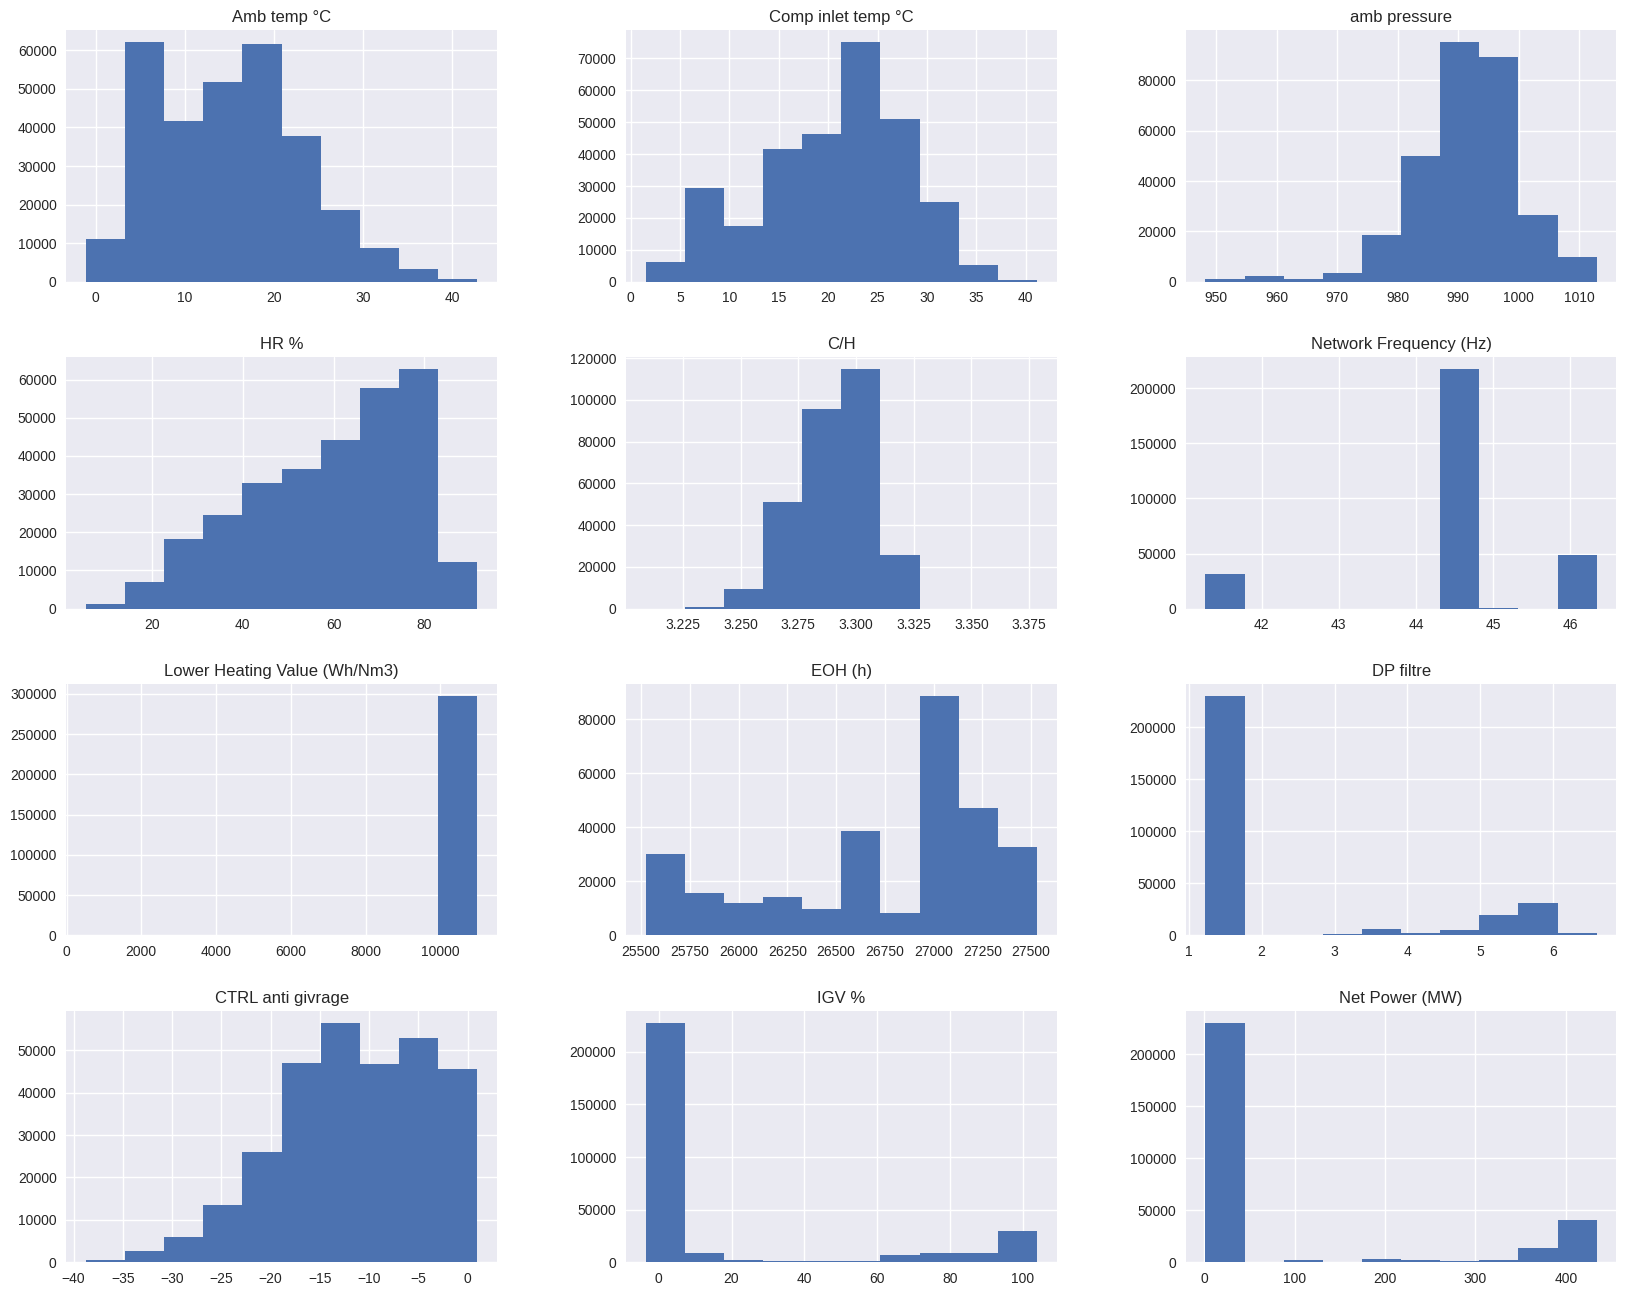

In [15]:
data.hist(figsize=(20,16))

## Net Power (MW)

<Axes: xlabel='time'>

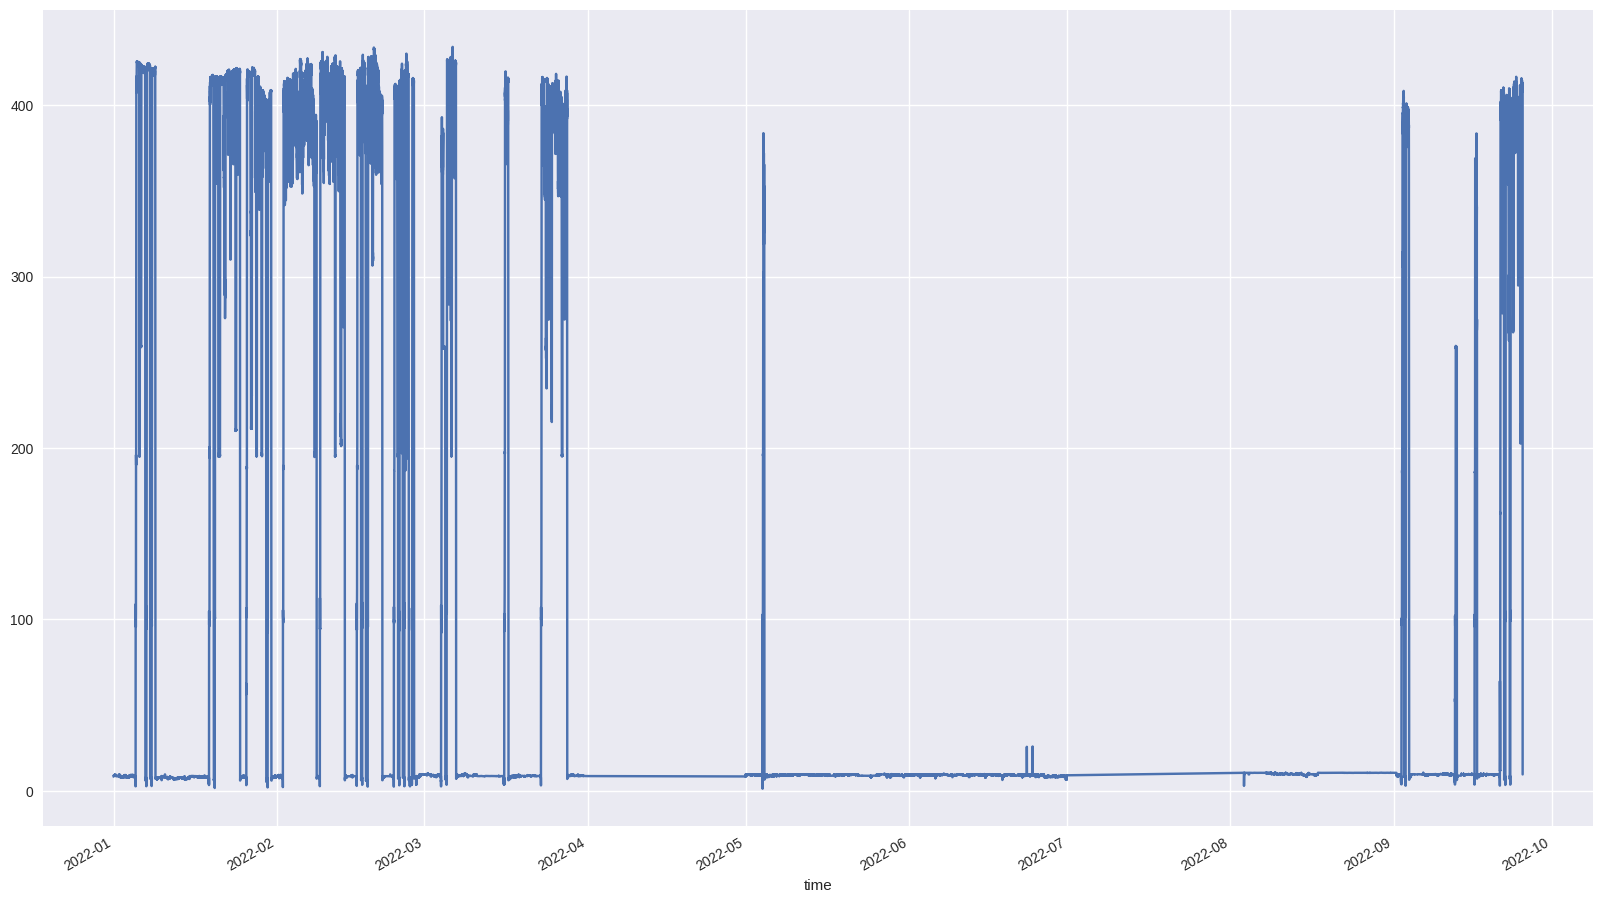

In [16]:
data["Net Power (MW)"].plot(figsize=(20,12))

Let's see if there is any correlation between the Net power (MW) and speed by taking a look at one of them, function of the other.

In [17]:
x_var = "Amb temp °C"
y_var = "Net Power (MW)"
# data.plot.scatter(x=x_var,y=y_var)

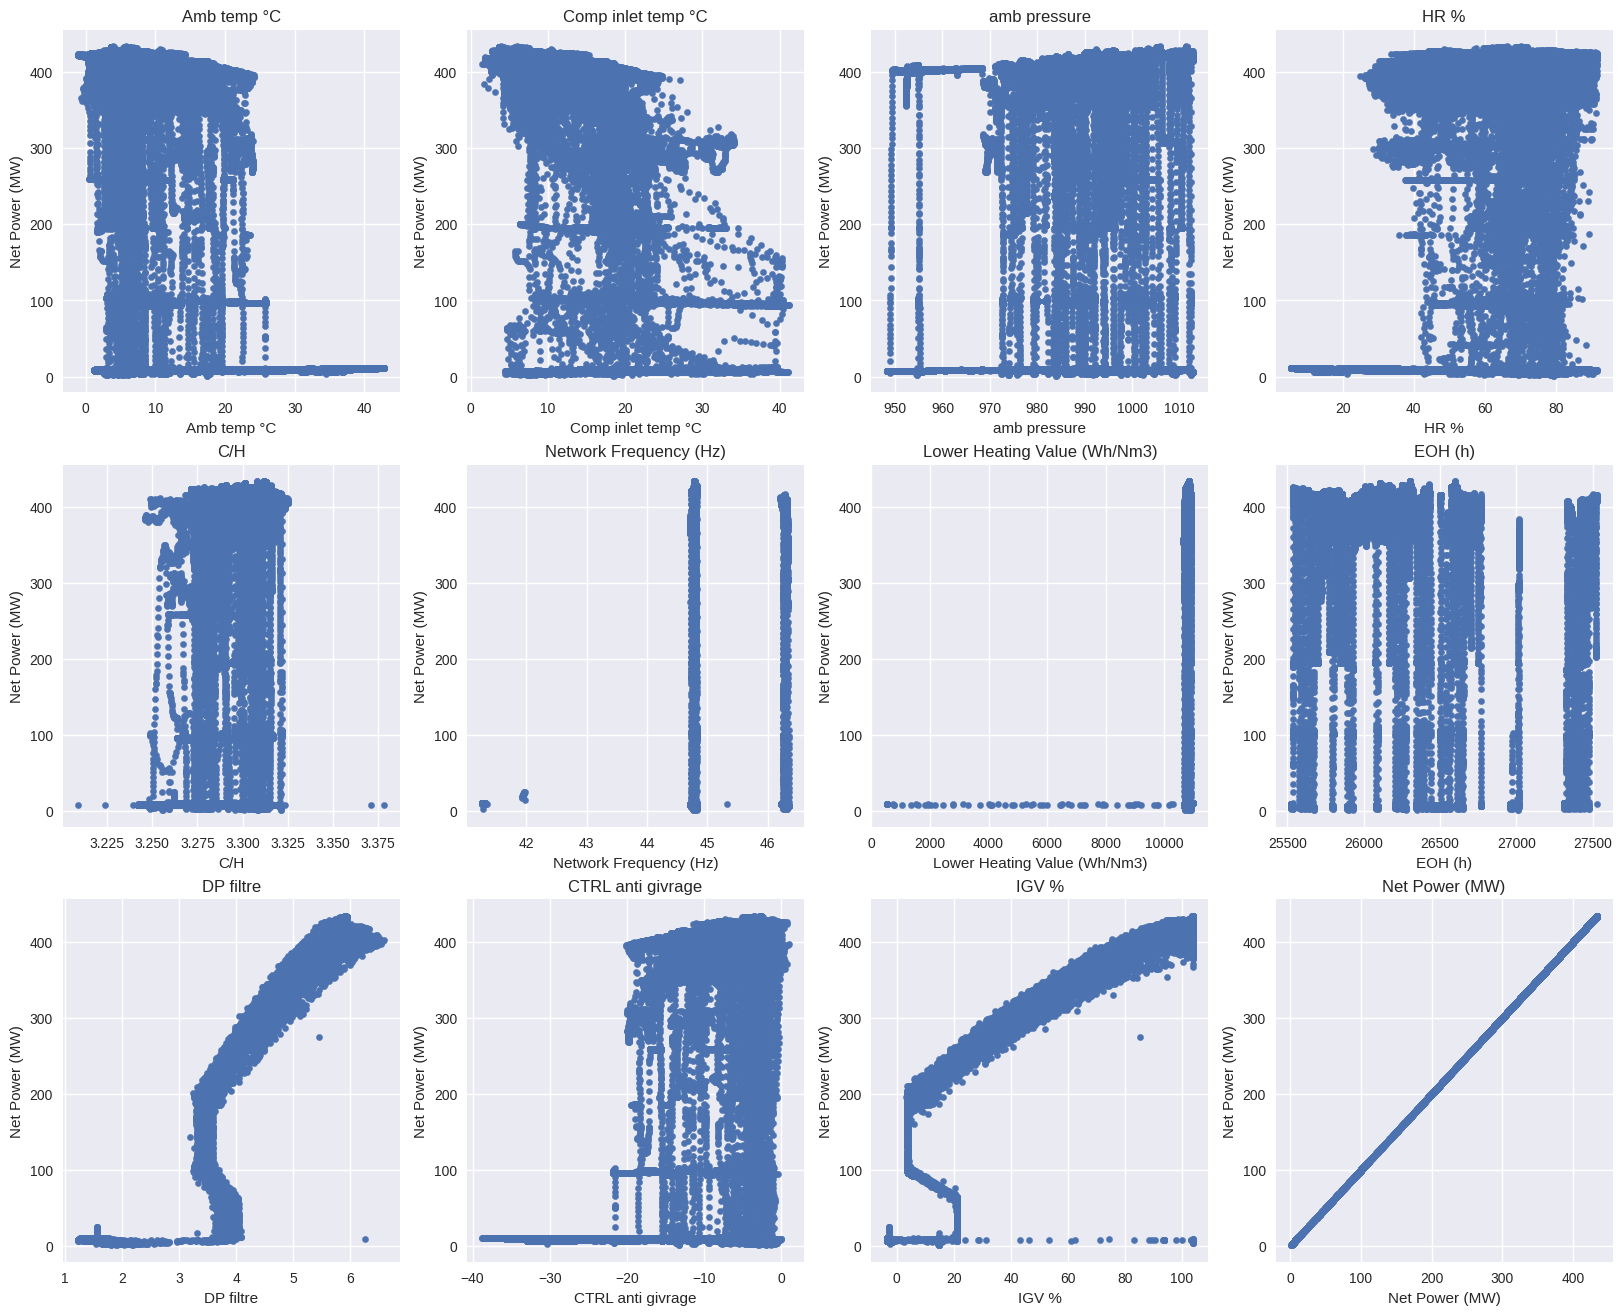

In [18]:
fig, ax = plt.subplots(figsize=(20,16),nrows=3, ncols=4)

for i,col in enumerate(data.columns):
    data.plot.scatter(x=col,y=y_var,ax=ax[i//4,i%4],title=col)

The correlation between the variables is not obvious expect for the variables 'DP filtre' and 'IGV %'. Let's take a closer look at the values of the correlations.

In [19]:
data.corr()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
Amb temp °C,1.000000,0.858408,-0.052619,-0.644495,-0.309121,-0.228648,-0.141386,0.754063,-0.450142,-0.988910,-0.452333,-0.458500
Comp inlet temp °C,0.858408,1.000000,-0.064032,-0.477497,-0.306185,-0.203256,-0.138780,0.729105,-0.707728,-0.841403,-0.727891,-0.721737
amb pressure,-0.052619,-0.064032,1.000000,-0.120541,0.069233,0.002156,-0.036160,-0.064529,0.000908,0.036456,-0.006627,0.003307
HR %,-0.644495,-0.477497,-0.120541,1.000000,0.073178,0.201953,0.054272,-0.381612,0.245039,0.691025,0.249846,0.242478
C/H,-0.309121,-0.306185,0.069233,0.073178,1.000000,-0.260343,0.349305,-0.368839,0.240334,0.273811,0.252348,0.254155
Network Frequency (Hz),-0.228648,-0.203256,0.002156,0.201953,-0.260343,1.000000,-0.068717,-0.074184,0.132849,0.239204,0.119270,0.118191
Lower Heating Value (Wh/Nm3),-0.141386,-0.138780,-0.036160,0.054272,0.349305,-0.068717,1.000000,-0.138673,0.105108,0.126118,0.110281,0.110424
EOH (h),0.754063,0.729105,-0.064529,-0.381612,-0.368839,-0.074184,-0.138673,1.000000,-0.393412,-0.733472,-0.418586,-0.412964
DP filtre,-0.450142,-0.707728,0.000908,0.245039,0.240334,0.132849,0.105108,-0.393412,1.000000,0.429456,0.974494,0.994440
CTRL anti givrage,-0.988910,-0.841403,0.036456,0.691025,0.273811,0.239204,0.126118,-0.733472,0.429456,1.000000,0.431732,0.436013


In [20]:
data.corr().style.background_gradient()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
Amb temp °C,1.000000,0.858408,-0.052619,-0.644495,-0.309121,-0.228648,-0.141386,0.754063,-0.450142,-0.988910,-0.452333,-0.458500
Comp inlet temp °C,0.858408,1.000000,-0.064032,-0.477497,-0.306185,-0.203256,-0.138780,0.729105,-0.707728,-0.841403,-0.727891,-0.721737
amb pressure,-0.052619,-0.064032,1.000000,-0.120541,0.069233,0.002156,-0.036160,-0.064529,0.000908,0.036456,-0.006627,0.003307
HR %,-0.644495,-0.477497,-0.120541,1.000000,0.073178,0.201953,0.054272,-0.381612,0.245039,0.691025,0.249846,0.242478
C/H,-0.309121,-0.306185,0.069233,0.073178,1.000000,-0.260343,0.349305,-0.368839,0.240334,0.273811,0.252348,0.254155
Network Frequency (Hz),-0.228648,-0.203256,0.002156,0.201953,-0.260343,1.000000,-0.068717,-0.074184,0.132849,0.239204,0.119270,0.118191
Lower Heating Value (Wh/Nm3),-0.141386,-0.138780,-0.036160,0.054272,0.349305,-0.068717,1.000000,-0.138673,0.105108,0.126118,0.110281,0.110424
EOH (h),0.754063,0.729105,-0.064529,-0.381612,-0.368839,-0.074184,-0.138673,1.000000,-0.393412,-0.733472,-0.418586,-0.412964
DP filtre,-0.450142,-0.707728,0.000908,0.245039,0.240334,0.132849,0.105108,-0.393412,1.000000,0.429456,0.974494,0.994440
CTRL anti givrage,-0.988910,-0.841403,0.036456,0.691025,0.273811,0.239204,0.126118,-0.733472,0.429456,1.000000,0.431732,0.436013


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Supprimer la colonne 'Net Power (MW)' du DataFrame
X = data.drop(columns=['Net Power (MW)'])

# Parcourir les colonnes x2, x3, x4 et afficher les coefficients de corrélation avec y
for column in X.columns:
    correlation_coefficient = X[column].corr(data['Net Power (MW)'])
    print(f"Corrélation entre {column} et y : {correlation_coefficient:.2f}")


Corrélation entre Amb temp °C et y : -0.46
Corrélation entre Comp inlet temp °C et y : -0.72
Corrélation entre amb pressure et y : 0.00
Corrélation entre HR % et y : 0.24
Corrélation entre C/H et y : 0.25
Corrélation entre Network Frequency (Hz) et y : 0.12
Corrélation entre Lower Heating Value (Wh/Nm3) et y : 0.11
Corrélation entre EOH (h) et y : -0.41
Corrélation entre DP filtre et y : 0.99
Corrélation entre CTRL anti givrage et y : 0.44
Corrélation entre IGV % et y : 0.98


'DP filtre' and 'IGV %' are highly correlated with the target variable.

For a sample, the correlation is defined by : 
    

$$
\frac{\sum \limits _{i=1} ^{n} (x_{i} - \bar x) (y_{i} - \bar y)}{\sqrt{\sum \limits _{i=1} ^{n}(x_{i} - \bar x)^{2}}\sqrt{\sum \limits _{i=1} ^{n}(y_{i} - \bar y)^{2}}} 
$$

What is important to recall is that it is comprised in the range $[-1, 1]$ and : <br>
    - it is equal to 1 if the two variables are exactly the same <br>
    - it is equal to -1 if the two variables are the exact opposite <br>
    - when it is equal to 0, the two variables have nothing in common : they are independent one from the other, for example this could be the value of the bitcoin and the average wind speed in south korea, we know these two have nothing in common.<br>
    - when it is > 0, the two variables are positively correlated, this means that on average, when one goes up, the other goes up too.<br>
    - when it is < 0, the two variables are negatively correlated, this means that on average, when one goes up, the other goes down.<br>

#### EDA ideas

- features selection: drop useless variables? why? how?
- handle the nan values differently
- create new variables ? 



## Modeling

Based on this first EDA, a very simple model we can try to predict our sample is to try a linear model : 

In order to do so, we import some libraries that will be useful.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

We now cut our dataframe in two : one dataframe will be used for training, and the other one will be used to estimate what is the value of this first model we have made. 
For this, why do we not directly use the test set ? The reason is that for the test set, we do not know the exact value of the power measurement.

In [23]:
# Supprimer plusieurs colonnes du DataFrame
columns_to_drop = ["amb pressure", "Network Frequency (Hz)", "Lower Heating Value (Wh/Nm3)"]
data.drop(columns=columns_to_drop, inplace=True)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 297316 entries, 2022-01-01 00:00:00 to 2022-09-25 12:15:00
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Amb temp °C         297316 non-null  float64
 1   Comp inlet temp °C  297316 non-null  float64
 2   HR %                297316 non-null  float64
 3   C/H                 297316 non-null  float64
 4   EOH (h)             297316 non-null  float64
 5   DP filtre           297316 non-null  float64
 6   CTRL anti givrage   297316 non-null  float64
 7   IGV %               297316 non-null  float64
 8   Net Power (MW)      297316 non-null  float64
dtypes: float64(9)
memory usage: 22.7 MB
None


In [24]:
X = data.drop(columns="Net Power (MW)")
y = data["Net Power (MW)"]

print(X.shape, y.shape)


(297316, 8) (297316,)


In [25]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y,test_size=0.2, shuffle=True,random_state=0)

In [26]:
def evaluate_model(model):
    #print("Model name: ", type(model).__name__)
    #print("Model parameters: ", model.get_params())

    # Printing model accuracy
    model_train_mae = mean_absolute_error(y_train,model.predict(X_train))
    model_test_mae = mean_absolute_error(y_eval,model.predict(X_eval))

    #print("Model Mean Absolute error on the train set : %.2f" % model_train_mae)
    #print("Model Mean Absolute error on the test set : %.2f" % model_test_mae)

    return model_train_mae , model_test_mae

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
evaluate_model(model)

(7.282076215107384, 7.274101663576174)

Nice ! We have our first model and it gives an error of 10.27 !..

Now wait, what is the value of that first model ? How can we know if 10.27 is actually a good error ? Well for this, a very neat way to be able to know if our model is worth anything is to compare it to a naive model. A naive model can be for example to predict everytime the same value, whatever the conditions. One of these naive model we have at hand would be to predict the mean value of the wind power in the train set. Let's see what would this model give. 

Yes ! Good news, our model did really learn something good ! We are a lot better than the 'mean' or 'median' model, around 10 times better, based on this metric.

# Next steps Modeling

We have already seen first models above : the linear model with all the variables , and two naive models (median, and mean). It will be your job from now on to determine the best model, but let's already take a look at one classic model that data scientists usually try on for nearly any subject : Random Forest. 

In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
# Tracé

def figure(x, y):
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, color='blue', label='Tracé')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Fonction de perte')
    plt.legend()


itération :  1 evaluate_model_test :  131.429177117963 evaluate_model_train :  131.64370040592576
itération :  50001 evaluate_model_test :  0.6550524418245476 evaluate_model_train :  0.5197079932958703
itération :  100001 evaluate_model_test :  0.5717557060161196 evaluate_model_train :  0.3626218776270442
itération :  150001 evaluate_model_test :  0.5328585619588846 evaluate_model_train :  0.27615016086046074
itération :  200001 evaluate_model_test :  0.5107866722851083 evaluate_model_train :  0.2146455182977756


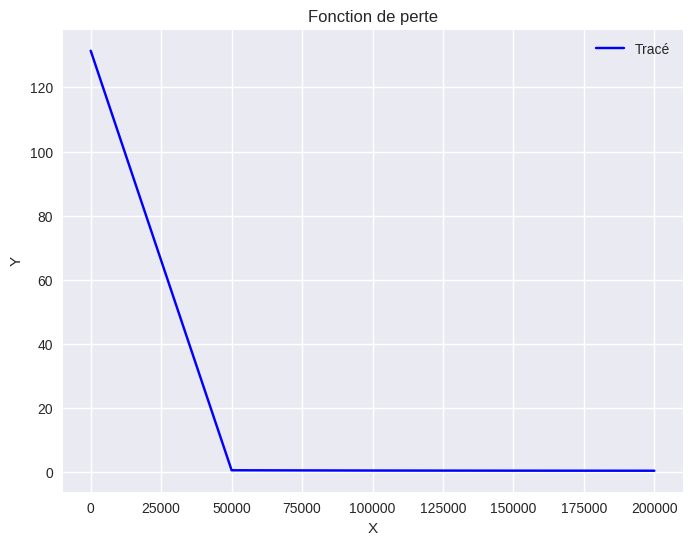

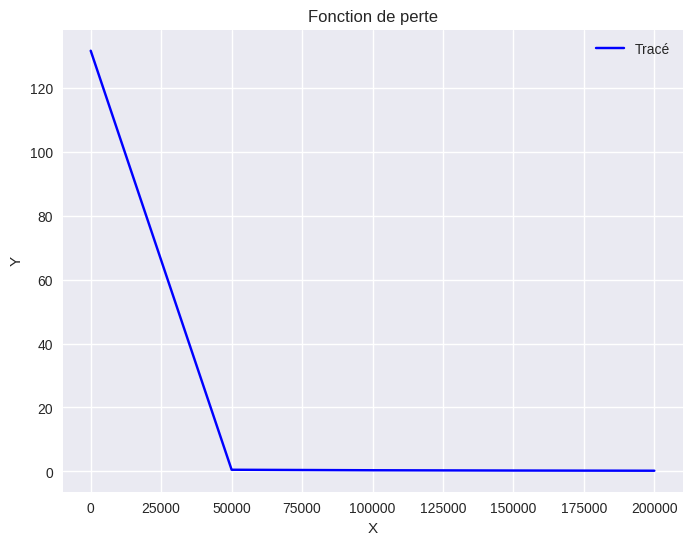

In [30]:
max_samples=237000
x=[]
y=[]
yy=[]

for i in range(1,max_samples + 1,50000):
    rf_model = RandomForestRegressor(n_jobs=-1,max_samples=i)
    rf_model.fit(X_train, y_train)
    evaluate_model_train , evaluate_model_test = evaluate_model(rf_model)
    
    x.append(i)
    y.append(evaluate_model_test)
    yy.append(evaluate_model_train)

    print("itération : ", i, "evaluate_model_test : ", evaluate_model_test, "evaluate_model_train : ",evaluate_model_train)

figure(x, y)
figure(x, yy)

Random Forest does better than the linear model.

In [31]:
#from sklearn.model_selection import cross_val_score, KFold

print(x,"\n\n\n\n\n",y,"\n\n\n\n\n",yy)

[1, 50001, 100001, 150001, 200001] 




 [131.429177117963, 0.6550524418245476, 0.5717557060161196, 0.5328585619588846, 0.5107866722851083] 




 [131.64370040592576, 0.5197079932958703, 0.3626218776270442, 0.27615016086046074, 0.2146455182977756]


[100001, 150001, 200001] 




 [0.5717557060161196, 0.5328585619588846, 0.5107866722851083] 




 [0.3626218776270442, 0.27615016086046074, 0.2146455182977756]


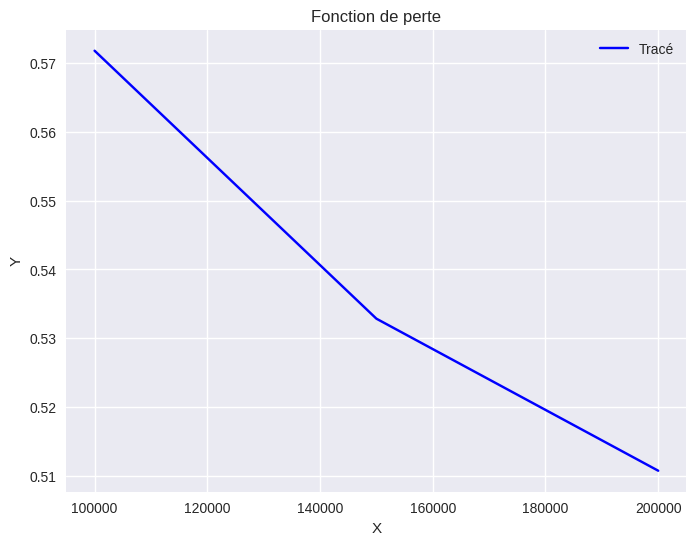

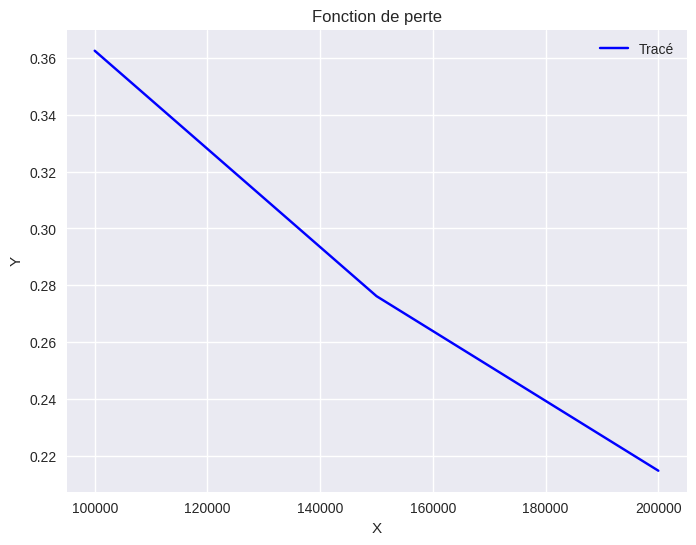

In [32]:
xx = x [2:]
yyy = y [2:]
yyyyyy = yy [2:]

print(xx,"\n\n\n\n\n",yyy,"\n\n\n\n\n",yyyyyy)

figure(xx,yyy)

figure (xx,yyyyyy)

## Cross Validation

In [33]:
#cv_rf_model = RandomForestRegressor(n_jobs=-1,max_samples=200)

In [34]:
"""
cv_scores = []
for i in range(2, 11):
    kfold = KFold(n_splits=i)
    scores = cross_val_score(cv_rf_model, X, y,scoring="neg_mean_absolute_error", cv=kfold)
    cv_scores.append(-scores.mean())

best_cv = cv_scores.index(max(cv_scores)) + 2
print(f"The best cross-validation split is {best_cv}-fold with a mean score of {max(cv_scores)}")
"""

'\ncv_scores = []\nfor i in range(2, 11):\n    kfold = KFold(n_splits=i)\n    scores = cross_val_score(cv_rf_model, X, y,scoring="neg_mean_absolute_error", cv=kfold)\n    cv_scores.append(-scores.mean())\n\nbest_cv = cv_scores.index(max(cv_scores)) + 2\nprint(f"The best cross-validation split is {best_cv}-fold with a mean score of {max(cv_scores)}")\n'

In [35]:
#X_train, X_eval, y_train, y_eval = train_test_split(X, y,test_size=1/best_cv, shuffle=True,random_state=0)

### Modeling ideas

- Try different parameters for the models ?
- Try new models ?
- Tune parameters ?


# Predictions on test set

Now our model is fit, we can pass on to the predictions.

_Note: be careful when generating your submission file. Indeed, it needs to be a csv file with ";" as separator._

In [36]:
selected_model = rf_model #cv_rf_model

In [37]:

columns_to_drop = ["amb pressure", "Network Frequency (Hz)", "Lower Heating Value (Wh/Nm3)","Net Power (MW)"]

X_test = test.drop(columns=columns_to_drop)


df_predictions = pd.DataFrame({
    'time': test.index,
    'Net Power (MW)': selected_model.predict(X_test),
})

df_predictions.to_csv('predictions.csv', date_format='%d/%m/%Y %H:%M',index=False, sep=';')
df_predictions.head()

,time,Net Power (MW)
0,2022-04-01 00:00:00,8.621845
1,2022-04-01 00:01:00,8.633593
2,2022-04-01 00:02:00,8.621232
3,2022-04-01 00:03:00,8.621698
4,2022-04-01 00:04:00,8.623883


Now it is your turn, what better model can you think of ?